Total frames: 1074

0: 384x640 3 persons, 1 sports ball, 12.5ms
Speed: 1.7ms preprocess, 12.5ms inference, 5.4ms postprocess per image at shape (1, 3, 384, 640)


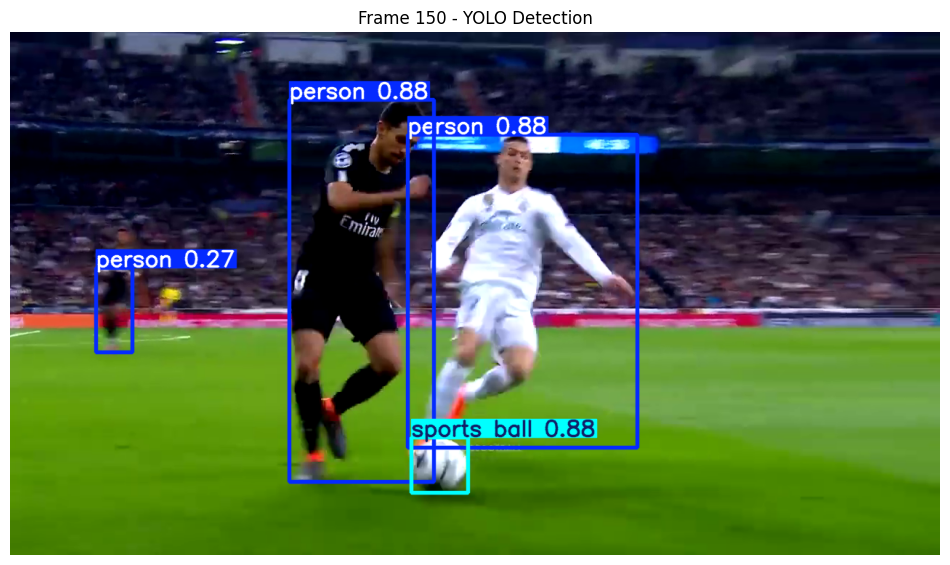


Detections found: 4
  sports ball: 0.88
  person: 0.88
  person: 0.88
  person: 0.27


In [20]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import torch
import numpy as np


# Load pre-trained model
model = YOLO('yolo11n.pt')

# Open the downloaded video file
video_path = 'soccer.mp4'
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error: Could not open video file")
else:
    # Select a frame
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames: {total_frames}")
    
    frame_number = 150
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # Read the frame
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        # Run YOLO on the frame
        results = model(frame)
        
        # Visualize results
        annotated_frame = results[0].plot()
        
        # Display detection result with frame
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Frame {frame_number} - YOLO Detection')
        plt.show()
        
        print(f"\nDetections found: {len(results[0].boxes)}")
        for box in results[0].boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]
            confidence = float(box.conf[0])
            print(f"  {class_name}: {confidence:.2f}")
    else:
        print("Failed to read frame")

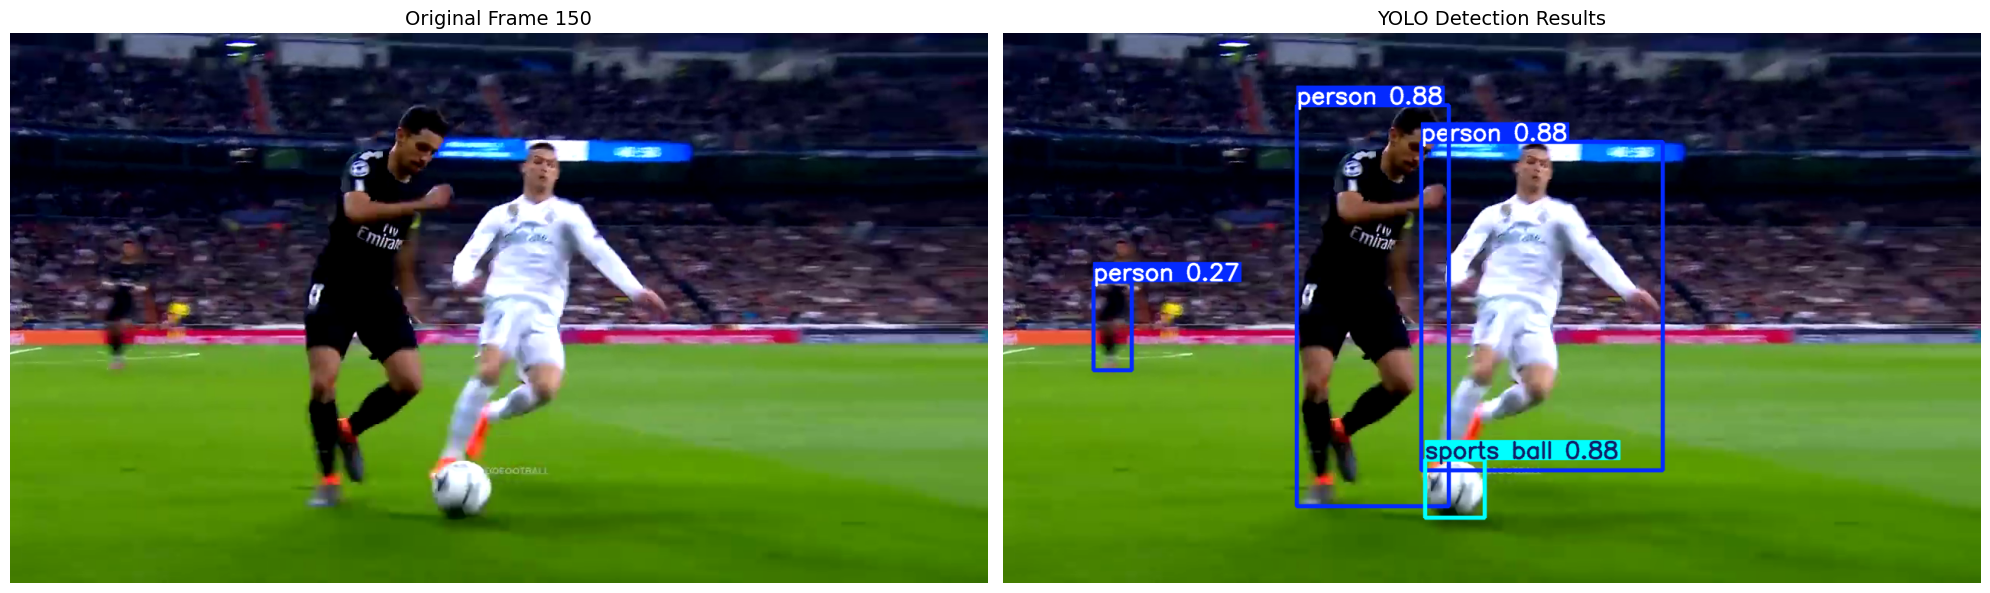

In [21]:
# Display original frame vs detection results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Original frame
ax1.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
ax1.set_title(f'Original Frame {frame_number}', fontsize=14)
ax1.axis('off')

# Detection results
ax2.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
ax2.set_title(f'YOLO Detection Results', fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

DETECTION ANALYSIS

Total detections: 4
Image size: 1280x720 pixels

--- Class Distribution ---
person:
  Count: 3
  Confidence - Avg: 0.674, Min: 0.265, Max: 0.879
sports ball:
  Count: 1
  Confidence - Avg: 0.883, Min: 0.883, Max: 0.883


/tmp/ipykernel_14582/855653854.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(conf_by_class, labels=class_names)


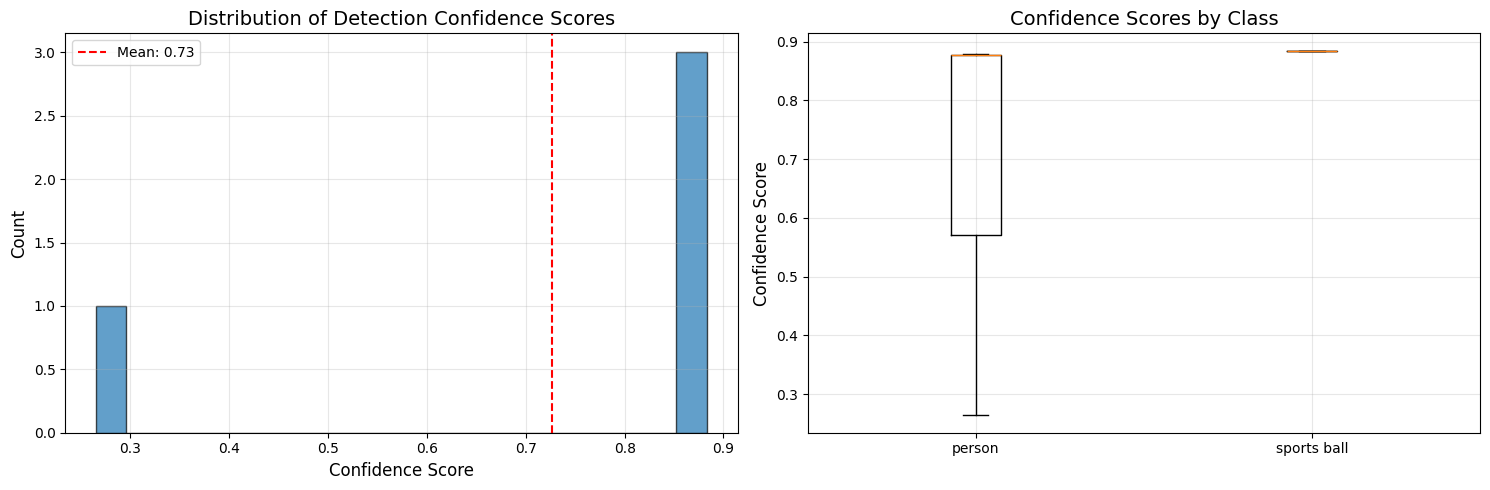

In [22]:
# Analyze detections
boxes = results[0].boxes
confidences = boxes.conf.cpu().numpy()
classes = boxes.cls.cpu().numpy()

print("=" * 60)
print("DETECTION ANALYSIS")
print("=" * 60)
print(f"\nTotal detections: {len(boxes)}")
print(f"Image size: {frame.shape[1]}x{frame.shape[0]} pixels")

# Class distribution
print("\n--- Class Distribution ---")
unique_classes = np.unique(classes)
for class_id in unique_classes:
    count = np.sum(classes == class_id)
    class_name = model.names[int(class_id)]
    class_confidences = confidences[classes == class_id]
    avg_conf = class_confidences.mean()
    min_conf = class_confidences.min()
    max_conf = class_confidences.max()
    print(f"{class_name}:")
    print(f"  Count: {count}")
    print(f"  Confidence - Avg: {avg_conf:.3f}, Min: {min_conf:.3f}, Max: {max_conf:.3f}")

# Confidence distribution visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
ax1.hist(confidences, bins=20, edgecolor='black', alpha=0.7)
ax1.axvline(confidences.mean(), color='red', linestyle='--', label=f'Mean: {confidences.mean():.2f}')
ax1.set_xlabel('Confidence Score', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Detection Confidence Scores', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# Box plot by class
class_names = [model.names[int(c)] for c in unique_classes]
conf_by_class = [confidences[classes == c] for c in unique_classes]
ax2.boxplot(conf_by_class, labels=class_names)
ax2.set_ylabel('Confidence Score', fontsize=12)
ax2.set_title('Confidence Scores by Class', fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

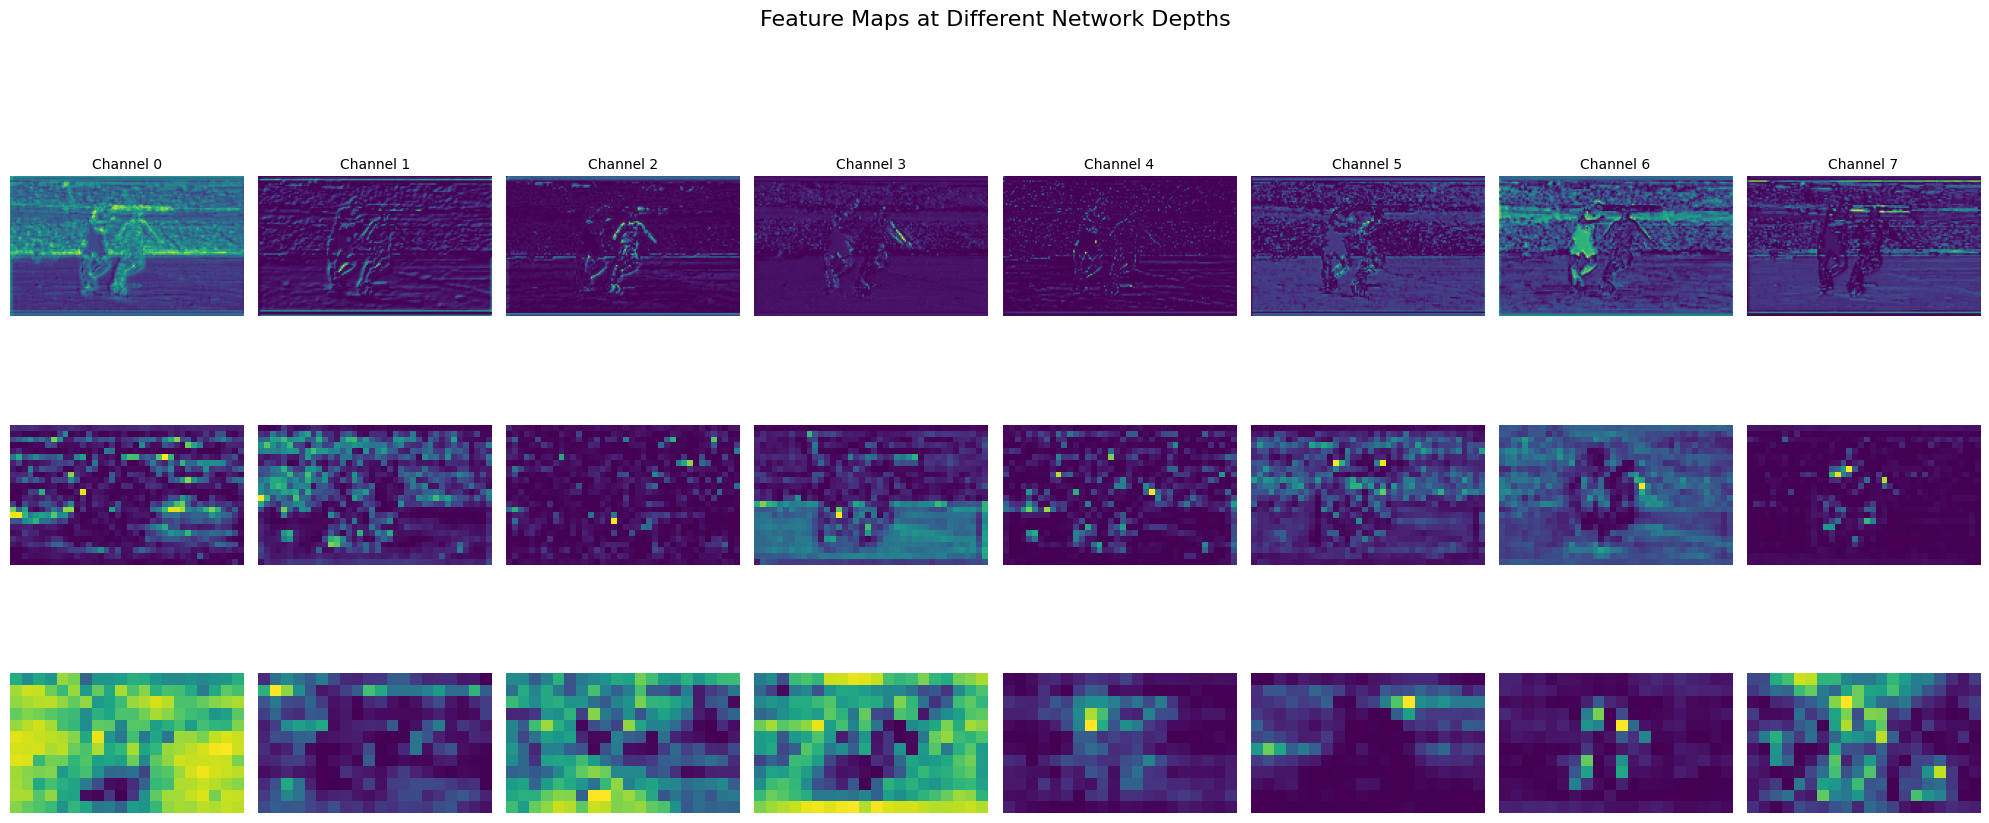


Feature Map Statistics:
Early Layer (Layer 2):
  Shape: torch.Size([1, 64, 96, 160]) (batch, channels, height, width)
  Value range: [-0.278, 15.519]

Middle Layer (Layer 6):
  Shape: torch.Size([1, 128, 24, 40]) (batch, channels, height, width)
  Value range: [-0.278, 5.623]

Deep Layer (Layer 9):
  Shape: torch.Size([1, 256, 12, 20]) (batch, channels, height, width)
  Value range: [-0.278, 3.354]



In [23]:
# Capture feature maps from intermediate layers
feature_maps = {}

def get_activation(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

# Register hooks on different layers
# YOLOv11 has layers at indices: 0-9 (backbone), 10-14 (neck), 15-22 (head)
layers_to_visualize = {
    'Early Layer (Layer 2)': 2,
    'Middle Layer (Layer 6)': 6,
    'Deep Layer (Layer 9)': 9,
}

hooks = []
for name, layer_idx in layers_to_visualize.items():
    hook = model.model.model[layer_idx].register_forward_hook(get_activation(name))
    hooks.append(hook)

# Run inference to capture feature maps
_ = model(frame, verbose=False)

# Visualize feature maps from different layers
fig, axes = plt.subplots(len(layers_to_visualize), 8, figsize=(20, 3*len(layers_to_visualize)))

for row_idx, (layer_name, layer_idx) in enumerate(layers_to_visualize.items()):
    fmap = feature_maps[layer_name][0]  # First image in batch
    
    # Display first 8 channels
    for col_idx in range(min(8, fmap.shape[0])):
        ax = axes[row_idx, col_idx] if len(layers_to_visualize) > 1 else axes[col_idx]
        
        channel = fmap[col_idx].cpu().numpy()
        im = ax.imshow(channel, cmap='viridis')
        ax.axis('off')
        
        if col_idx == 0:
            ax.set_ylabel(layer_name, fontsize=10, rotation=0, ha='right', va='center')
        if row_idx == 0:
            ax.set_title(f'Channel {col_idx}', fontsize=10)

plt.suptitle('Feature Maps at Different Network Depths', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Remove hooks
for hook in hooks:
    hook.remove()

print(f"\n{'='*60}")
print("Feature Map Statistics:")
print(f"{'='*60}")
for name, fmap in feature_maps.items():
    print(f"{name}:")
    print(f"  Shape: {fmap.shape} (batch, channels, height, width)")
    print(f"  Value range: [{fmap.min():.3f}, {fmap.max():.3f}]")
    print()

NON-MAXIMUM SUPPRESSION ANALYSIS
Detections before NMS (conf>0.01): 20
Detections after NMS (conf>0.25, IoU<0.45): 4
Boxes removed: 16 (80.0%)


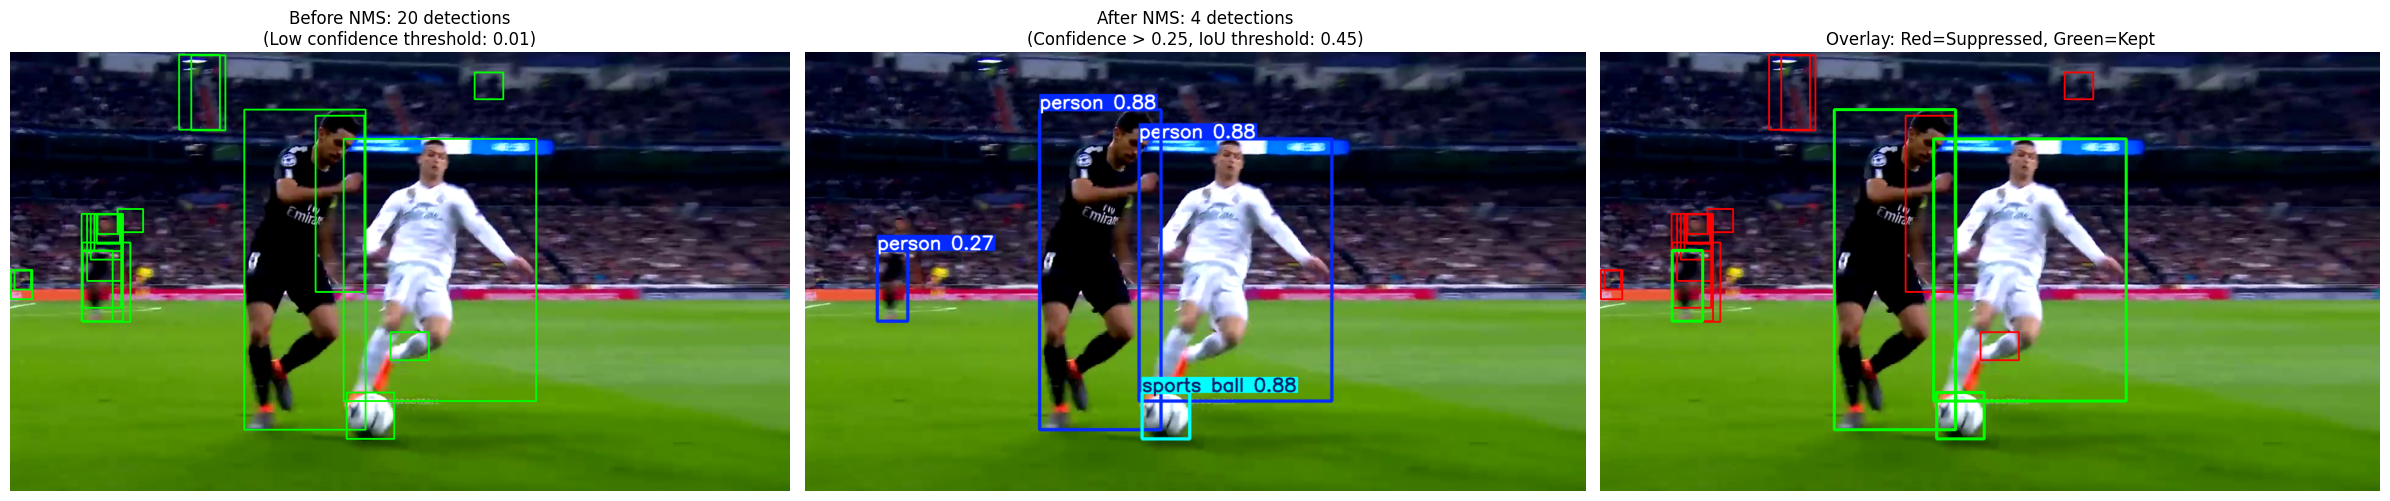

In [24]:
# Run detection with very low confidence to see all raw predictions
results_raw = model(frame, conf=0.01, iou=0.7, verbose=False)  # High IoU = less suppression
results_nms = model(frame, conf=0.25, iou=0.45, verbose=False)  # Normal NMS

raw_boxes = results_raw[0].boxes
nms_boxes = results_nms[0].boxes

print(f"{'='*60}")
print("NON-MAXIMUM SUPPRESSION ANALYSIS")
print(f"{'='*60}")
print(f"Detections before NMS (conf>0.01): {len(raw_boxes)}")
print(f"Detections after NMS (conf>0.25, IoU<0.45): {len(nms_boxes)}")
print(f"Boxes removed: {len(raw_boxes) - len(nms_boxes)} ({(1-len(nms_boxes)/max(len(raw_boxes),1))*100:.1f}%)")

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Before NMS (all low-confidence detections)
img_before = frame.copy()
for box in raw_boxes.xyxy.cpu().numpy():
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(img_before, (x1, y1), (x2, y2), (0, 255, 0), 2)

axes[0].imshow(cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB))
axes[0].set_title(f'Before NMS: {len(raw_boxes)} detections\n(Low confidence threshold: 0.01)', fontsize=12)
axes[0].axis('off')

# After NMS
img_after = results_nms[0].plot()
axes[1].imshow(cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'After NMS: {len(nms_boxes)} detections\n(Confidence > 0.25, IoU threshold: 0.45)', fontsize=12)
axes[1].axis('off')

# Overlay showing removed boxes
img_overlay = frame.copy()
# Draw removed boxes in red
for box in raw_boxes.xyxy.cpu().numpy():
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(img_overlay, (x1, y1), (x2, y2), (0, 0, 255), 2)
# Draw kept boxes in green
for box in nms_boxes.xyxy.cpu().numpy():
    x1, y1, x2, y2 = box.astype(int)
    cv2.rectangle(img_overlay, (x1, y1), (x2, y2), (0, 255, 0), 3)

axes[2].imshow(cv2.cvtColor(img_overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Overlay: Red=Suppressed, Green=Kept', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [25]:
def calculate_iou(box1, box2):
    """Calculate Intersection over Union between two boxes"""
    x1_min, y1_min, x1_max, y1_max = box1
    x2_min, y2_min, x2_max, y2_max = box2
    
    # Calculate intersection
    inter_min_x = max(x1_min, x2_min)
    inter_min_y = max(y1_min, y2_min)
    inter_max_x = min(x1_max, x2_max)
    inter_max_y = min(y1_max, y2_max)
    
    inter_width = max(0, inter_max_x - inter_min_x)
    inter_height = max(0, inter_max_y - inter_min_y)
    inter_area = inter_width * inter_height
    
    # Calculate union
    box1_area = (x1_max - x1_min) * (y1_max - y1_min)
    box2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0

# Demonstrate IoU calculation with actual detections
if len(nms_boxes) >= 2:
    boxes_xyxy = nms_boxes.xyxy.cpu().numpy()
    
    print(f"\n{'='*60}")
    print("IoU CALCULATION EXAMPLES")
    print(f"{'='*60}")
    
    # Calculate IoU between first few boxes
    num_examples = min(3, len(boxes_xyxy))
    for i in range(num_examples):
        for j in range(i+1, num_examples):
            iou = calculate_iou(boxes_xyxy[i], boxes_xyxy[j])
            print(f"IoU between box {i} and box {j}: {iou:.4f}")
            if iou > 0.45:
                print(f"Would be suppressed if IoU threshold was 0.45")
            else:
                print(f"Kept (IoU < 0.45)")


IoU CALCULATION EXAMPLES
IoU between box 0 and box 1: 0.0174
Kept (IoU < 0.45)
IoU between box 0 and box 2: 0.0076
Kept (IoU < 0.45)
IoU between box 1 and box 2: 0.0676
Kept (IoU < 0.45)



PERFORMANCE METRICS
Average inference time: 22.94 ms
FPS (Frames Per Second): 43.60
Min time: 15.65 ms
Max time: 50.54 ms
Std deviation: 10.59 ms

MODEL INFORMATION
Model: YOLOv11n (nano)
Input size: (720, 1280, 3)
Number of classes: 80
Classes of interest: person (class 0), sports ball (class 32)


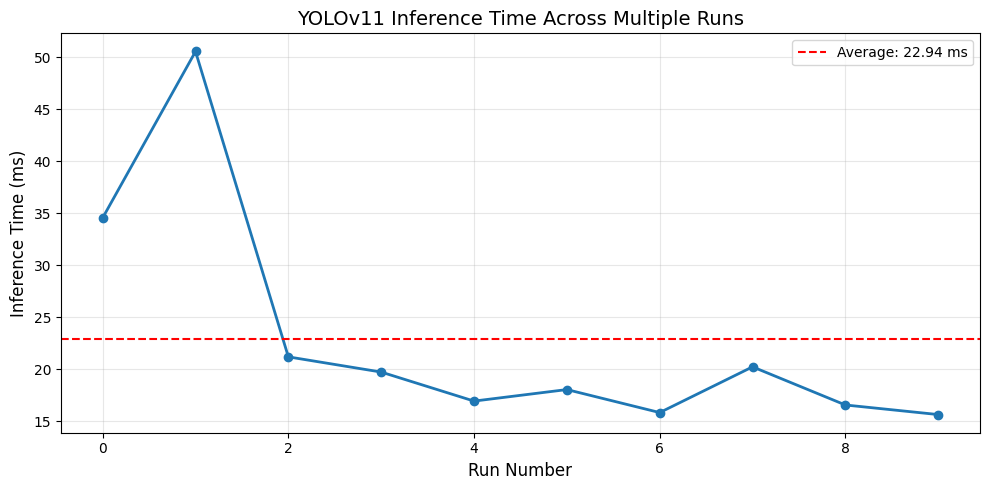

In [26]:
import time

# Measure inference time
inference_times = []
for _ in range(10):
    start = time.time()
    _ = model(frame, verbose=False)
    end = time.time()
    inference_times.append((end - start) * 1000)  # Convert to ms

avg_time = np.mean(inference_times)
fps = 1000 / avg_time

print(f"\n{'='*60}")
print("PERFORMANCE METRICS")
print(f"{'='*60}")
print(f"Average inference time: {avg_time:.2f} ms")
print(f"FPS (Frames Per Second): {fps:.2f}")
print(f"Min time: {min(inference_times):.2f} ms")
print(f"Max time: {max(inference_times):.2f} ms")
print(f"Std deviation: {np.std(inference_times):.2f} ms")

# Model information
print(f"\n{'='*60}")
print("MODEL INFORMATION")
print(f"{'='*60}")
print(f"Model: YOLOv11n (nano)")
print(f"Input size: {frame.shape}")
print(f"Number of classes: {len(model.names)}")
print(f"Classes of interest: person (class {list(model.names.keys())[list(model.names.values()).index('person')]}), sports ball (class {list(model.names.keys())[list(model.names.values()).index('sports ball')]})")

# Visualize inference time distribution
plt.figure(figsize=(10, 5))
plt.plot(inference_times, marker='o', linestyle='-', linewidth=2)
plt.axhline(avg_time, color='r', linestyle='--', label=f'Average: {avg_time:.2f} ms')
plt.xlabel('Run Number', fontsize=12)
plt.ylabel('Inference Time (ms)', fontsize=12)
plt.title('YOLOv11 Inference Time Across Multiple Runs', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()